In [13]:
using DifferentialEquations
using Plots
using LinearAlgebra

In [41]:
#LinRange(start, stop, length)

In [44]:
LinRange(0.0, 1.0, 5)

5-element LinRange{Float64, Int64}:
 0.0, 0.25, 0.5, 0.75, 1.0

In [52]:
function RK4(f, t_span, y0, h)

    """
    f :: the right-hand side of the ODE y' = f(t,y)
    t_span :: tuple of the initial and final times for integration
    y0 :: the initial condition; y(0) = y0
    h :: the step size for the integration 
    """
    
    #Solve the ODE y' = f(t,y), y'(0) = y0 on (t_span[1], t_span[end])  
    
    t0 = t_span[1]       #Initial time
    tf = t_span[end]     #Final time 

    N = Int(floor((tf - t0) / h))      #The number of steps (iterations).
    t = LinRange(t0, tf, N + 1)        #t = [t0, t1, t2,..., t_N], a vector of length N + 1.  
    
    #Create an array of length N whose elements are the additive identity element for objects of type y0. 
    y = [zero(y0) for _ in 1:N+1]

    y[1] = y0
    
    for n=1:N     #n+1 = 2,3,...,N+1  (remember: length(y) = N + 1) 

        k1 = f(t[n], y[n])
        k2 = f(t[n] + h/2, y[n] + h * k1/2)
        k3 = f(t[n] + h/2, y[n] + h * k2/2)
        k4 = f(t[n] + h, y[n] + h * k3)

        y[n+1] = y[n] + (h/6)*(k1 + 2*k2 + 2*k3 + k4)
    end

    return t, y

end

RK4 (generic function with 2 methods)

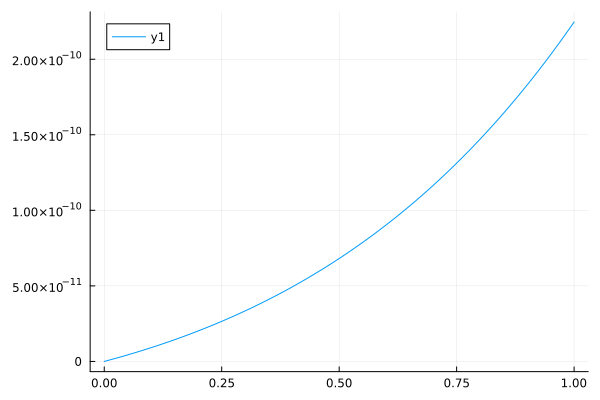

In [68]:
#Test 1: Solving dy/dt = y, y(0) = 1  (Exponential growth)
function f1(t, y)
    return y
end

t, y_approx = RK4(f1, (0.0, 1.0), 1.0, 0.01)
y_true = exp.(t)
error = y_true - y_approx
plot(t, error)

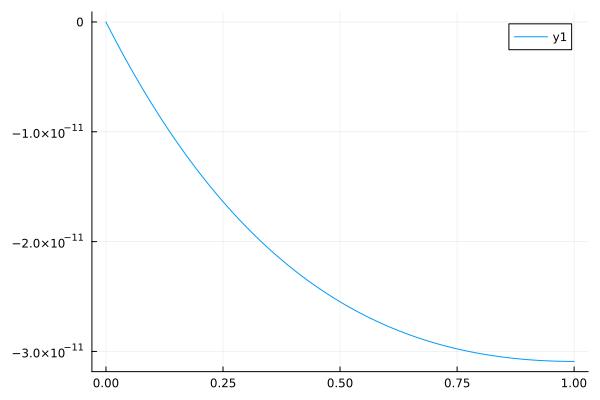

In [70]:
#Test 2: Solving dy/dt = -y, y(0) = 1  (Exponential decay)
function f2(t, y)
    return -y
end

t, y_approx = RK4(f2, (0.0, 1.0), 1.0, 0.01)
y_true = exp.(-t)
error = y_true - y_approx
plot(t, error)

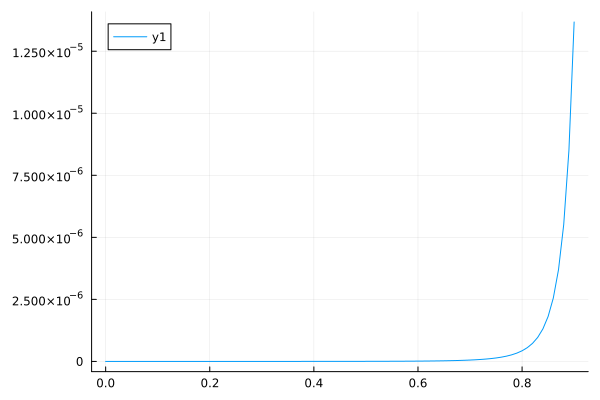

In [77]:
#Test 3: Solving dy/dt = y^2, y(0) = 1  (Blow up at t = 1)
function f3(t, y)
    return y^2 
end

y3(t) = 1/(1 - t)
t, y_approx = RK4(f3, (0.0, 0.9), 1.0, 0.01)
y_true = y3.(t)
error = y_true - y_approx
plot(t, error)

In [11]:
#Given an object of type T, how do I create a vector of length N whose entries are the zero element
#for objects of type T? 

In [ ]:
A = 

In [10]:
?zeros

search: zeros count_zeros set_zero_subnormals get_zero_subnormals leading_zeros



```
zeros([T=Float64,] dims::Tuple)
zeros([T=Float64,] dims...)
```

Create an `Array`, with element type `T`, of all zeros with size specified by `dims`. See also [`fill`](@ref), [`ones`](@ref), [`zero`](@ref).

# Examples

```jldoctest
julia> zeros(1)
1-element Vector{Float64}:
 0.0

julia> zeros(Int8, 2, 3)
2×3 Matrix{Int8}:
 0  0  0
 0  0  0
```
